In [1]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import os

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

save_dir = "data/xenium/processed"
os.makedirs(save_dir, exist_ok=True)

Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr


In [2]:
data_dir = "/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR"
!ls $data_dir

 Analysis
 QC.ipynb
'TCR_Xenium Slide ID_0029040.docx'
'TCR_Xenium Slide ID_0029041.docx'
'Thymus _fast_check.ipynb'
 ToUpload
 __pycache__
 celltype_sample
 celltype_sample.ipynb
 classified_base.h5ad
 ct_sample.zip
 init_classify_base.ipynb
 output-XETG00088__0029040__Region_1__20240719__095641
 output-XETG00088__0029040__Region_2__20240719__095641
 output-XETG00088__0029040__Region_3__20240719__095641
 output-XETG00088__0029040__Region_4__20240719__095642
 output-XETG00088__0029040__Region_5__20240719__095642
 output-XETG00088__0029040__Region_6__20240719__095642
 output-XETG00088__0029040__Region_7__20240719__095642
 output-XETG00088__0029041__Region_1__20240719__095642
 output-XETG00088__0029041__Region_2__20240719__095642
 output-XETG00088__0029041__Region_3__20240719__095642
 output-XETG00088__0029041__Region_4__20240719__095642
 output-XETG00088__0029041__Region_5__20240719__095642
 output-XETG00088__0029041__Region_6__20240719__095642
 output-XETG00088__0029041__Region_7__2024

In [3]:
adatas = []
metadatas = []
for folder in os.listdir(data_dir):
    if folder.startswith("output"):
        adata = sc.read_10x_h5(os.path.join(data_dir, folder, "cell_feature_matrix.h5"))
        adata.obs["sample"] = folder.split("-")[-1]
        cells = pd.read_parquet(
            os.path.join(data_dir, folder, "cells.parquet")
        ).set_index("cell_id")

        adata.obs.index = adata.obs.index + folder
        cells.index = cells.index + folder

        adatas.append(adata)
        metadatas.append(cells)

In [4]:
adata = ad.concat(adatas, uns_merge="unique")
obs = pd.concat(metadatas, axis=0)
obs = obs.loc[adata.obs.index]

adata.obsm["spatial"] = obs.iloc[:, :2].values
adata.obs[obs.columns] = obs
print(adata.obs["cell_area"].isna().sum())

0


In [5]:
adata.obs["slide"] = adata.obs["sample"].str.split("__").str[1]

In [6]:
adata.obs["slide"].value_counts()

slide
0029040    723757
0029041    365529
Name: count, dtype: int64

In [7]:
adata.layers["counts"] = adata.X.copy()

In [8]:
# add meta information?

In [9]:
adata.obs["sample"].value_counts()

sample
XETG00088__0029040__Region_1__20240719__095641    474645
XETG00088__0029041__Region_1__20240719__095642     89371
XETG00088__0029040__Region_7__20240719__095642     54143
XETG00088__0029040__Region_6__20240719__095642     50960
XETG00088__0029041__Region_4__20240719__095642     50676
XETG00088__0029041__Region_2__20240719__095642     44730
XETG00088__0029041__Region_3__20240719__095642     44621
XETG00088__0029041__Region_8__20240719__095642     44598
XETG00088__0029040__Region_2__20240719__095641     43526
XETG00088__0029040__Region_4__20240719__095642     41251
XETG00088__0029041__Region_5__20240719__095642     41112
XETG00088__0029041__Region_7__20240719__095642     34980
XETG00088__0029040__Region_3__20240719__095641     32584
XETG00088__0029040__Region_5__20240719__095642     26648
XETG00088__0029041__Region_6__20240719__095642     15441
Name: count, dtype: int64

/tmp/ipykernel_146127/3372648345.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="CD4", spot_size=15)


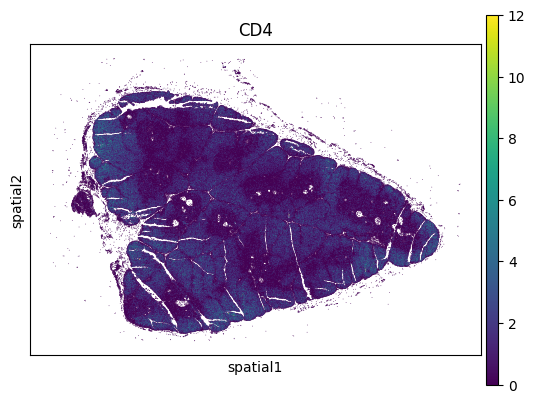

In [10]:
# remove thymus sample
sample = "XETG00088__0029040__Region_1__20240719__095641"
ad_sub = adata[adata.obs["sample"] == sample].copy()
sc.pl.spatial(ad_sub, color="CD4", spot_size=15)

In [11]:
adata = adata[adata.obs["sample"] != sample].copy()

## Basic quality control

In [12]:
adata

AnnData object with n_obs × n_vars = 614641 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide'
    obsm: 'spatial'
    layers: 'counts'

In [13]:
adata.obs.cell_area

aaaaocef-1output-XETG00088__0029041__Region_2__20240719__095642     25.874532
aaabpgpp-1output-XETG00088__0029041__Region_2__20240719__095642     56.309846
aaaccamo-1output-XETG00088__0029041__Region_2__20240719__095642    107.562191
aaahpepd-1output-XETG00088__0029041__Region_2__20240719__095642     38.427970
aaaifhap-1output-XETG00088__0029041__Region_2__20240719__095642    102.369222
                                                                      ...    
ojhpiocb-1output-XETG00088__0029040__Region_5__20240719__095642    135.333286
ojibodbj-1output-XETG00088__0029040__Region_5__20240719__095642    151.950787
ojicdocl-1output-XETG00088__0029040__Region_5__20240719__095642     68.050471
ojidgecb-1output-XETG00088__0029040__Region_5__20240719__095642    143.461411
ojiihaoj-1output-XETG00088__0029040__Region_5__20240719__095642     12.282500
Name: cell_area, Length: 614641, dtype: float64

In [14]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

In [15]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.007911735895767883
Negative decoding count % : 0.005614928051063053


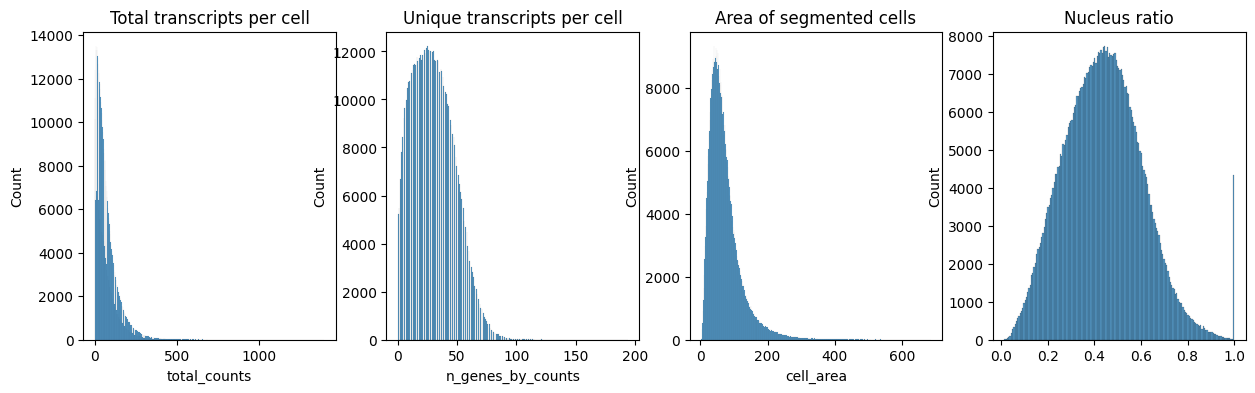

In [16]:
def plot_qc(adata):
    fig, axs = plt.subplots(1, 4, figsize=(15, 4))

    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        adata.obs["total_counts"],
        kde=False,
        ax=axs[0],
    )

    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        adata.obs["n_genes_by_counts"],
        kde=False,
        ax=axs[1],
    )

    axs[2].set_title("Area of segmented cells")
    sns.histplot(
        adata.obs["cell_area"],
        kde=False,
        ax=axs[2],
    )

    axs[3].set_title("Nucleus ratio")
    sns.histplot(
        adata.obs["nucleus_area"] / adata.obs["cell_area"],
        kde=False,
        ax=axs[3],
    )


plot_qc(adata)

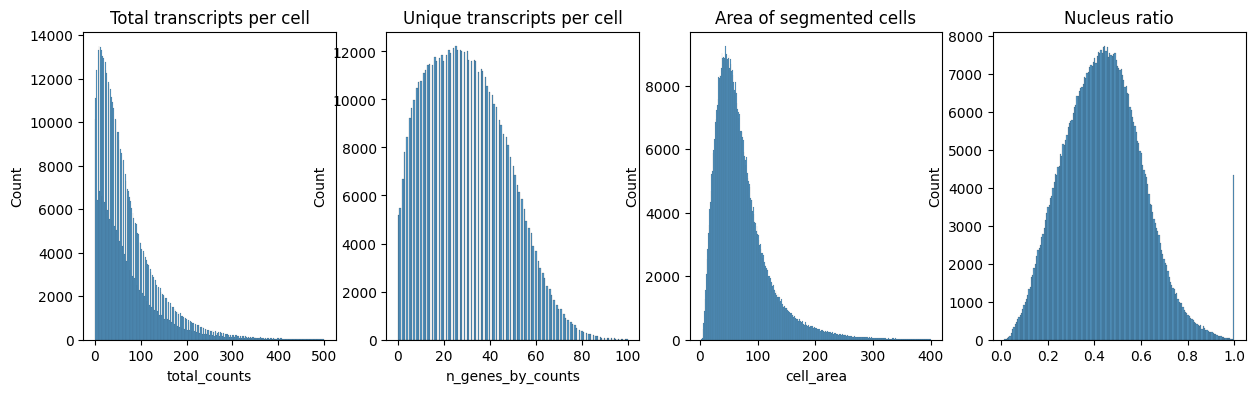

In [17]:
# filter by total transcripts, total unique transcripts, cell area

total_transcripts_limit = 500
unique_transcripts_limit = 100
cell_area_limit = 400

adata = adata[
    (adata.obs["total_counts"] <= total_transcripts_limit)
    & (adata.obs["n_genes_by_counts"] <= unique_transcripts_limit)
    & (adata.obs["cell_area"] <= cell_area_limit)
].copy()
plot_qc(adata)

(553399, 480)

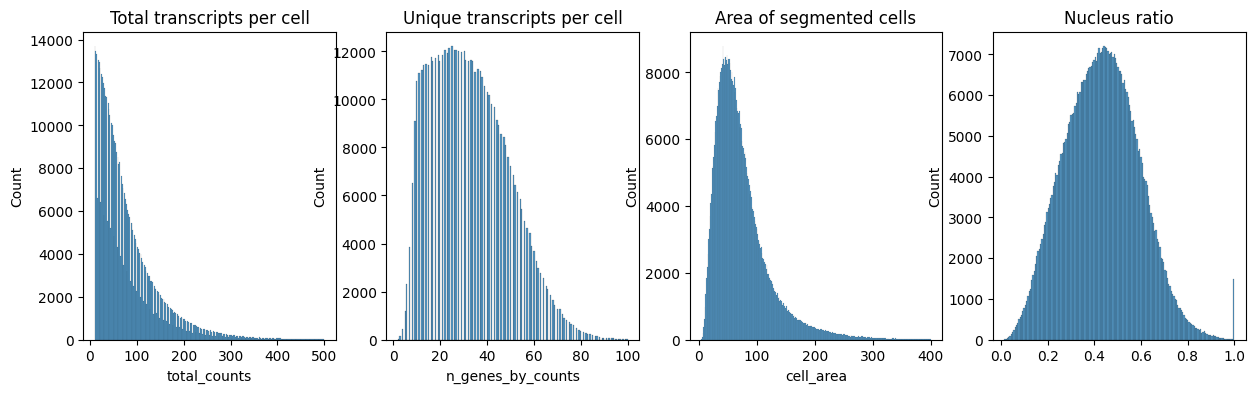

In [18]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)
plot_qc(adata)
adata.shape

## Add metadata

In [19]:
disease_info = {
    "Control": [
        "XETG00088__0029040__Region_2__20240719__095641",
        "XETG00088__0029040__Region_3__20240719__095641",
        "XETG00088__0029041__Region_1__20240719__095642",
    ],
    "ANCA": [
        "XETG00088__0029040__Region_4__20240719__095642",
        "XETG00088__0029040__Region_5__20240719__095642",
        "XETG00088__0029040__Region_6__20240719__095642",
        "XETG00088__0029040__Region_7__20240719__095642",
        "XETG00088__0029041__Region_3__20240719__095642",
        "XETG00088__0029041__Region_4__20240719__095642",
        "XETG00088__0029041__Region_5__20240719__095642",
        "XETG00088__0029041__Region_6__20240719__095642",
        "XETG00088__0029041__Region_7__20240719__095642",
        "XETG00088__0029041__Region_8__20240719__095642",
    ],
    "BK-Virus": ["XETG00088__0029041__Region_2__20240719__095642"],
}

/tmp/ipykernel_146127/821452480.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="CD3D", spot_size=15, cmap="Reds", vmax=1)


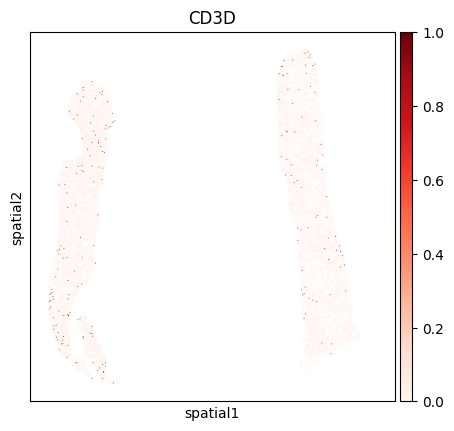

/tmp/ipykernel_146127/821452480.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="CD3D", spot_size=15, cmap="Reds", vmax=1)


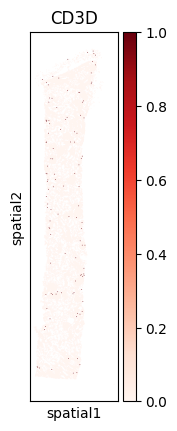

/tmp/ipykernel_146127/821452480.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="CD3D", spot_size=15, cmap="Reds", vmax=1)


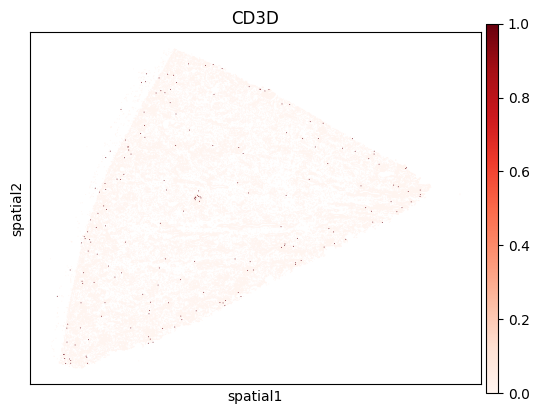

In [20]:
for s in disease_info["Control"]:
    ad_sub = adata[adata.obs["sample"] == s].copy()
    sc.pl.spatial(ad_sub, color="CD3D", spot_size=15, cmap="Reds", vmax=1)

In [21]:
adata.obs["condition"] = adata.obs["sample"]

for condition, samples in disease_info.items():
    mask = adata.obs["sample"].isin(samples)
    adata.obs.loc[mask, "condition"] = condition
adata.obs["condition"].value_counts()

condition
ANCA        389589
Control     120818
BK-Virus     42992
Name: count, dtype: int64

/tmp/ipykernel_146127/3063821923.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="CD4", spot_size=15)


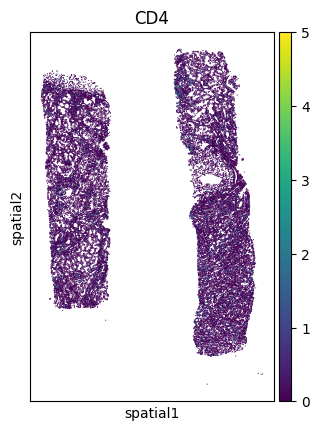

In [22]:
ad_sub = adata[adata.obs["condition"] == "BK-Virus"].copy()
sc.pl.spatial(ad_sub, color="CD4", spot_size=15)

In [23]:
adata.obs["condition"].value_counts()

condition
ANCA        389589
Control     120818
BK-Virus     42992
Name: count, dtype: int64

## Remove BK-Virus samples

In [24]:
adata = adata[adata.obs["condition"] != "BK-Virus"].copy()
adata.obs["condition"].value_counts()

condition
ANCA       389589
Control    120818
Name: count, dtype: int64

## Save anndata

In [25]:
adata.write_h5ad(f"{save_dir}/01-kidney_tcr_qc.h5ad")